# Modeling U.S. Credit Response to Rising Interest Rates 

## Step 1: Imports & Environment Setup

### Imports

In [76]:
import os
import sys
from pathlib import Path
from typing import Dict, Any

import yaml
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Verfiy Assets

In [77]:
logger = logging.getLogger("consumer-credit-analysis")

SECRETS_PATH = "../secrets.yaml"

if Path(SECRETS_PATH).exists():
        logger.info("secrets.yaml is properly configured.")
else:
    logger.info('secrets.yaml is not properly configured. Create a secrets.yaml file and add in your FRED API Key. i.e. `FRED_API_KEY:"XXXXXXXXXXXXXXXXXXXXXXX"`')


### Load Secrets File

In [78]:
def _load_yaml_file(path: str, name: str) -> Dict[str, Any]:
    """
    Helper to load any YAML file with a consistent error message.
    """
    abs_path = os.path.abspath(path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"{name} file not found at: {abs_path}")
    with open(abs_path, "r") as f:
        return yaml.safe_load(f) or {}

def load_secrets(secrets_path: str = "secrets.yaml") -> Dict[str, Any]:
    """
    Load application secrets from a YAML file.
    Args:
        secrets_path: Path to the secrets YAML file.

    Returns:
        Secrets dict.

    Raises:
        FileNotFoundError: If the secrets file is not found.
    """
    # If using an external secrets manager, you can create
    # an (empty) secrets.yaml stub in this path to satisfy the loader.
    return _load_yaml_file(secrets_path, "secrets.yaml")

secrets = load_secrets(SECRETS_PATH)
logger.info("Secrets Loaded")

### Setup FRED API Key

In [79]:
api_key = secrets.get("FRED_API_KEY")
fred = Fred(api_key=api_key)
logger.info("FRED API Key Successfully Setup.")

## Step 2: Data Download + Cleaning

In [80]:
# Download data
credit = fred.get_series('TOTALSL')
revolving = fred.get_series('REVOLSL')
nonrev = fred.get_series('NONREVSL')
fedfunds = fred.get_series('FEDFUNDS')
lending = fred.get_series('DRCCLACBS')


# Combine
df = pd.DataFrame({
    'credit_total': credit,
    'revolving': revolving,
    'nonrevolving': nonrev,
    'fedfunds': fedfunds,
    'lending_std': lending
})

df = df.dropna()
logger.info("Datasets loaded and cleaned.")

## Step 3: Exploratory Data Analysis (EDA)

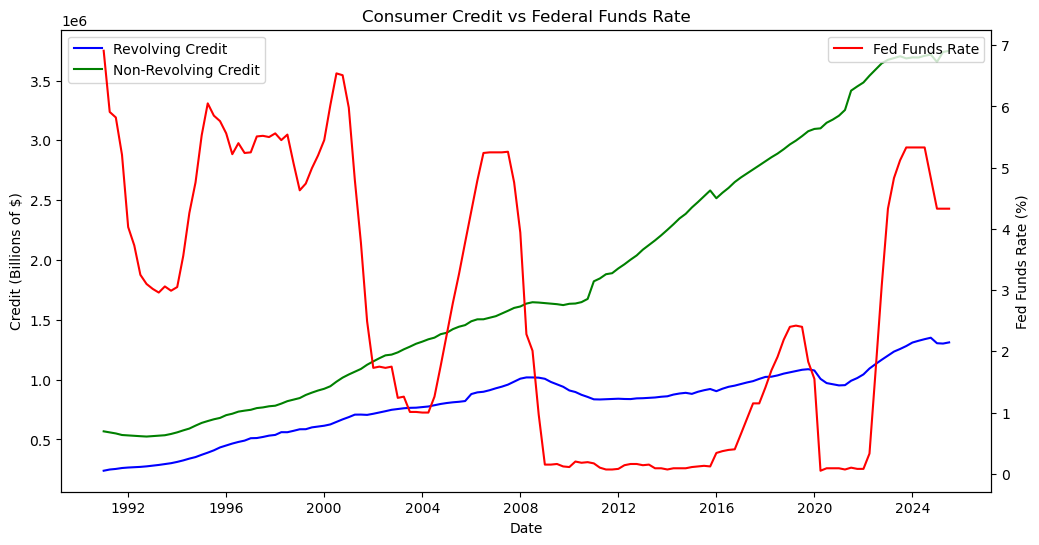

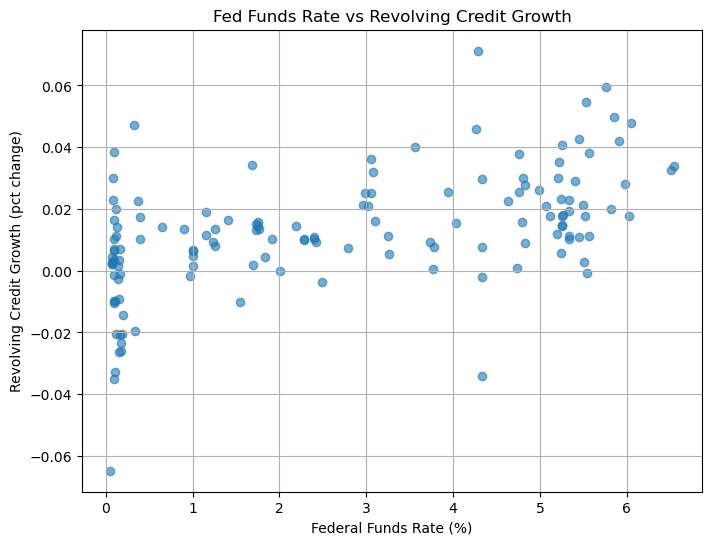

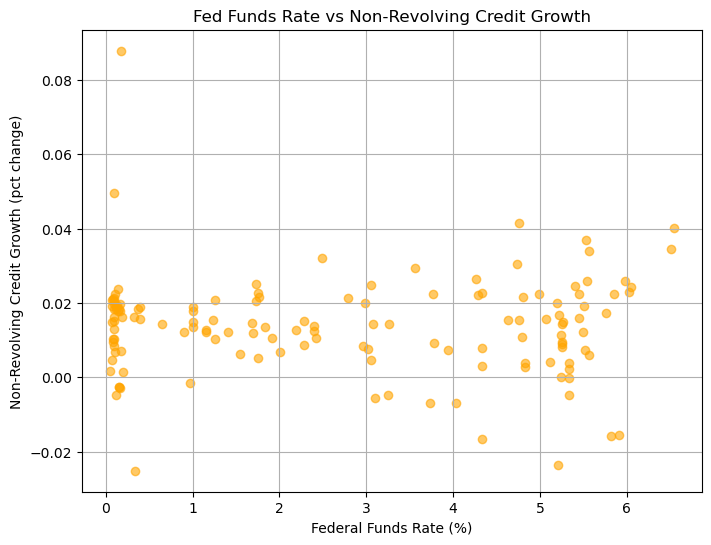

In [81]:
# --- Growth rate calculations ---
df['revolving_growth'] = df['revolving'].pct_change()
df['nonrev_growth'] = df['nonrevolving'].pct_change()

# ---------------------------------------------------------------
# TIME-SERIES PLOT with dual y-axes (so fed funds is visible)
# ---------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot credit levels
ax1.plot(df.index, df['revolving'], label='Revolving Credit', color='blue')
ax1.plot(df.index, df['nonrevolving'], label='Non-Revolving Credit', color='green')
ax1.set_xlabel("Date")
ax1.set_ylabel("Credit (Billions of $)")
ax1.legend(loc="upper left")

# Second axis for Fed Funds Rate
ax2 = ax1.twinx()
ax2.plot(df.index, df['fedfunds'], label='Fed Funds Rate', color='red')
ax2.set_ylabel("Fed Funds Rate (%)")
ax2.legend(loc="upper right")

plt.title("Consumer Credit vs Federal Funds Rate")
plt.show()

# ---------------------------------------------------------------
# SCATTER PLOTS (Cleaned for NaNs)
# ---------------------------------------------------------------
df_scatter = df[['fedfunds', 'revolving_growth', 'nonrev_growth']].dropna()

# Revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['revolving_growth'], alpha=0.6)
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Revolving Credit Growth")
plt.grid(True)
plt.show()

# Non-revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['nonrev_growth'], alpha=0.6, color='orange')
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Non-Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Non-Revolving Credit Growth")
plt.grid(True)
plt.show()


## Step 4: Modeling

### Model 1a: Linear Regression for revolving credit growth (12month)
Question: Do higher interest rates reduce revolving credit growth?

Without Lending Standards

With Lending Standards

In [82]:
df["revolving_growth_12m"] = df["revolving"].pct_change(12)
df["nonrev_growth_12m"] = df["nonrevolving"].pct_change(12)

# Lagged Fed Funds rate: consumers respond with delay
for lag in [0, 3, 6, 12]:
    df[f"fedfunds_lag{lag}"] = df["fedfunds"].shift(lag)

for lag in [0, 3, 6]:
    df[f"lending_lag{lag}"] = df["lending_std"].shift(lag)

df_model = df[[
    "revolving_growth_12m",
    "nonrev_growth_12m",
    
    # Fed Funds lags
    "fedfunds_lag0",
    "fedfunds_lag3",
    "fedfunds_lag6",
    "fedfunds_lag12",

    # NEW: lending standards features
    "lending_lag0",
    "lending_lag3",
    "lending_lag6",
]].dropna()


print("Model dataframe shape:", df_model.shape)
display(df_model.head())


Model dataframe shape: (127, 9)


,revolving_growth_12m,nonrev_growth_12m,fedfunds_lag0,fedfunds_lag3,fedfunds_lag6,fedfunds_lag12,lending_lag0,lending_lag3,lending_lag6
1994-01-01,0.309184,-0.014766,3.05,2.96,3.25,6.91,3.60,4.46,4.98
1994-04-01,0.306628,0.030226,3.56,3.06,3.10,5.91,3.29,4.08,4.69
1994-07-01,0.339844,0.074289,4.26,2.99,3.02,5.82,3.25,3.91,4.60
1994-10-01,0.349843,0.145962,4.76,3.05,2.96,5.21,3.29,3.60,4.46
1995-01-01,0.401741,0.196395,5.53,3.56,3.06,4.03,3.48,3.29,4.08


In [83]:

features_m1 = [
    "fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12",
    "lending_lag0", "lending_lag3", "lending_lag6"
]
features_m2 = [
    "fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12",
    "lending_lag0", "lending_lag3", "lending_lag6"
]

target_m1 = "revolving_growth_12m"

X1 = df_model[features_m1]
y1 = df_model[target_m1]

# keep time order (no shuffle) so it's more like train on past, test on future
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, shuffle=False
)

model1_ext = LinearRegression().fit(X1_train, y1_train)
y1_pred = model1_ext.predict(X1_test)

r2_1 = r2_score(y1_test, y1_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_pred))

print("=== Model 1 - Linear Regression (Revolving 12m Growth) ===")
print("Coefficients:")
for name, coef in zip(features_m1, model1_ext.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model1_ext.intercept_:.4f}")
print(f"R^2 (test): {r2_1:.3f}")
print(f"RMSE (test): {rmse_1:.4f}")


=== Model 1 - Linear Regression (Revolving 12m Growth) ===
Coefficients:
  fedfunds_lag0: 0.0437
  fedfunds_lag3: -0.0008
  fedfunds_lag6: 0.0247
  fedfunds_lag12: 0.0363
  lending_lag0: 0.0027
  lending_lag3: -0.0015
  lending_lag6: -0.1039
Intercept: 0.3102
R^2 (test): -0.144
RMSE (test): 0.1566


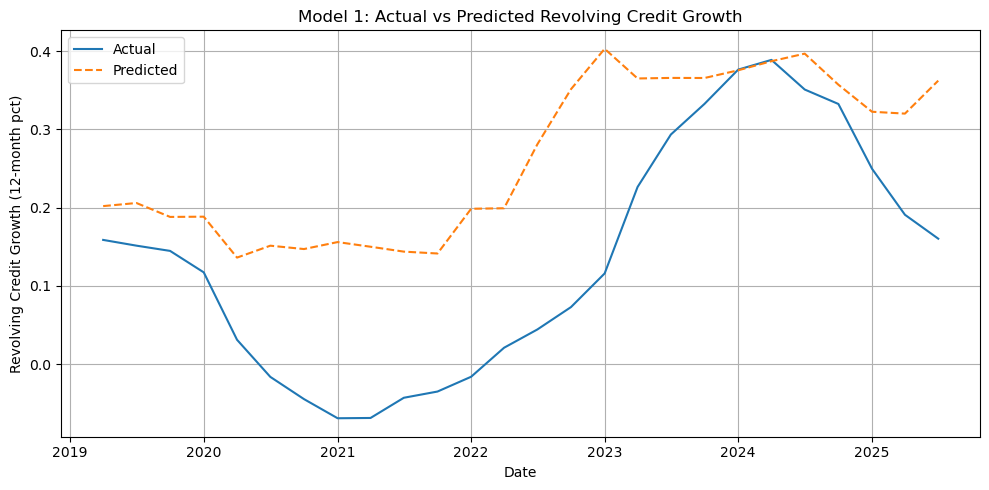

In [84]:
plt.figure(figsize=(10,5))
plt.plot(y1_test.index, y1_test, label="Actual", linewidth=1.5)
plt.plot(y1_test.index, y1_pred, label="Predicted", linestyle="--", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Revolving Credit Growth (12-month pct)")
plt.title("Model 1: Actual vs Predicted Revolving Credit Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Model 1b: Random Forest for revolving credit growth (12month)
With Lending Standards

### Model 2a: Linear Regression for non-revolving credit growth
Question: Is non-revolving credit less sensitive to rate changes?

### Without Lending Standards

### With Lending Standards

### Model 2b: Random Forest for non-revolving credit growth

In [85]:
X1 = df_model[features_m1]
y1 = df_model["revolving_growth_12m"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, shuffle=False
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3
).fit(X1_train, y1_train)

y1_pred_rf = rf_model.predict(X1_test)

print("R?:", r2_score(y1_test, y1_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y1_test, y1_pred_rf)))

importances = pd.Series(rf_model.feature_importances_, index=features_m1)
display(importances.sort_values(ascending=False))


R?: 0.3190620342730468
RMSE: 0.12083347736850883


fedfunds_lag3     0.531713
fedfunds_lag6     0.131852
lending_lag6      0.129212
fedfunds_lag0     0.125586
fedfunds_lag12    0.030498
lending_lag3      0.026679
lending_lag0      0.024460
dtype: float64

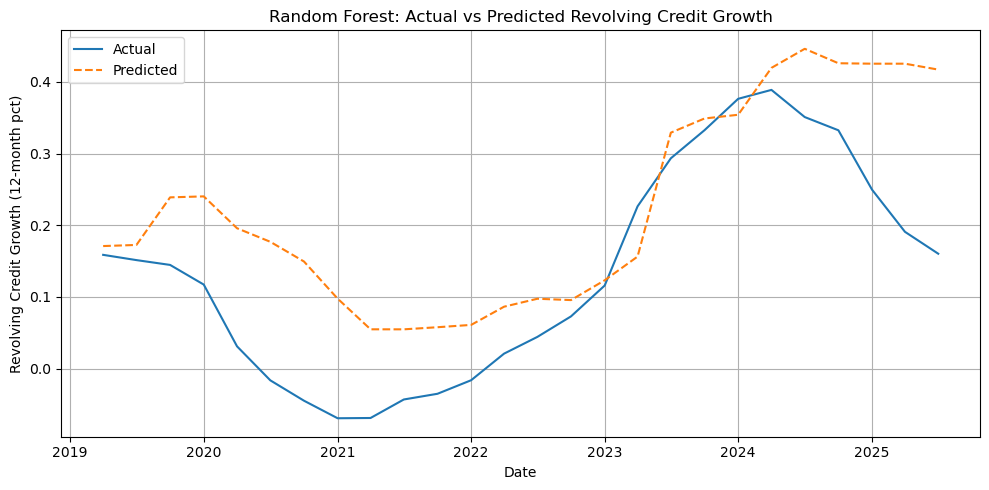

In [86]:
plt.figure(figsize=(10,5))
plt.plot(y1_test.index, y1_test, label="Actual", linewidth=1.5)
plt.plot(y1_test.index, y1_pred_rf, label="Predicted", linestyle="--", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Revolving Credit Growth (12-month pct)")
plt.title("Random Forest: Actual vs Predicted Revolving Credit Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
